# K-Means Clustering

K-means clustering is an unsupervised learning algorithm that groups data points into a specified number of clusters (k) based on their similarities, minimizing the distance between points in the same cluster. It is commonly used in data analysis for tasks like market segmentation and image compression

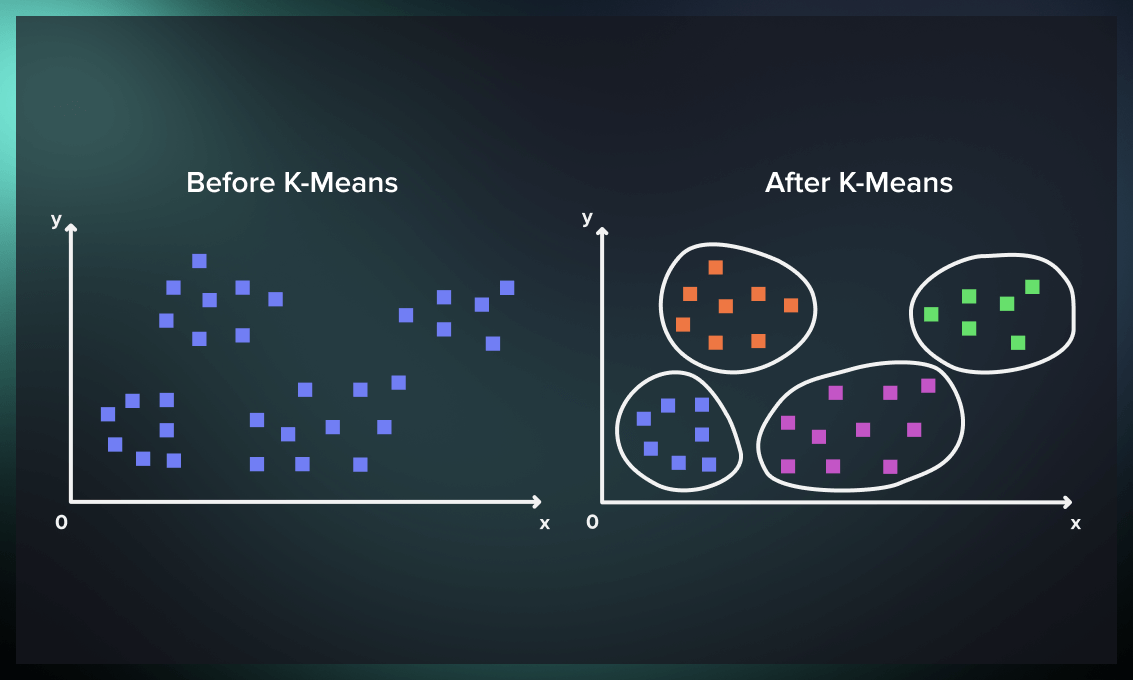

### Task: Apply K-means in a 'mall custumers data' to find relationship between Spending score and  customer's age

### Libraries

In [1]:
# importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### Load Dataset

In [2]:
#importing the Iris dataset with pandas
dataset = pd.read_csv('MallCustomers.csv')

In [3]:
dataset

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Gender
0,1,19,15,39,Male
1,2,21,15,81,Male
2,3,20,16,6,Female
3,4,23,16,77,Female
4,5,31,17,40,Female
...,...,...,...,...,...
195,196,35,120,79,Female
196,197,45,126,28,Female
197,198,32,126,74,Male
198,199,32,137,18,Male


### Data preparation

Selecting only Age and Spending score

In [103]:
x = dataset[['Age','Spending Score (1-100)']].values

### K-Means

In [104]:
from sklearn.cluster import KMeans

In [111]:
km= KMeans(n_clusters=3, max_iter=300, n_init= 10, random_state = 0)

**n_clusters** The number of clusters in k-means clustering, denoted as "k".


**max_iter** parameter in k-means clustering specifies the maximum number of iterations the algorithm will run before stopping. 

**n_init** pecifies the number of times the algorithm will run with different initial centroid seeds.

**random_state** parameter is used to control the randomness of the initial centroid positions. 

### Predction

In [112]:
pred = km.fit_predict(x)

In [113]:
pred

array([1, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 1, 2,
       0, 2, 0, 2, 1, 1, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 1, 2, 1, 1,
       0, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2,
       1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 0, 2, 1, 2, 0, 2, 0, 2,
       1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 1, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2], dtype=int32)

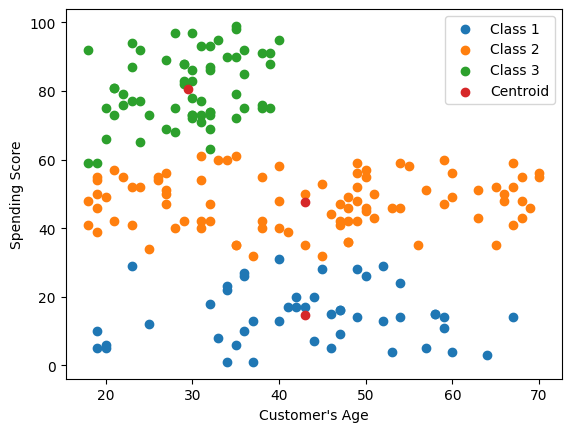

In [114]:
plt.scatter(x[pred==0,0],x[pred==0,1],label= 'Class 1')
plt.scatter(x[pred==1,0],x[pred==1,1],label= 'Class 2')
plt.scatter(x[pred==2,0],x[pred==2,1],label= 'Class 3')
# centroids
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1:2], label='Centroid')

plt.xlabel("Customer's Age")
plt.ylabel('Spending Score')
plt.legend()
plt.show()

### Elbow Method

The elbow method is a technique used in k-means clustering to determine the optimal number of clusters by plotting the within-cluster sum of squares (WCSS) against the number of clusters and identifying the "elbow" point where adding more clusters yields diminishing returns. This point indicates the most suitable number of clusters for the data set

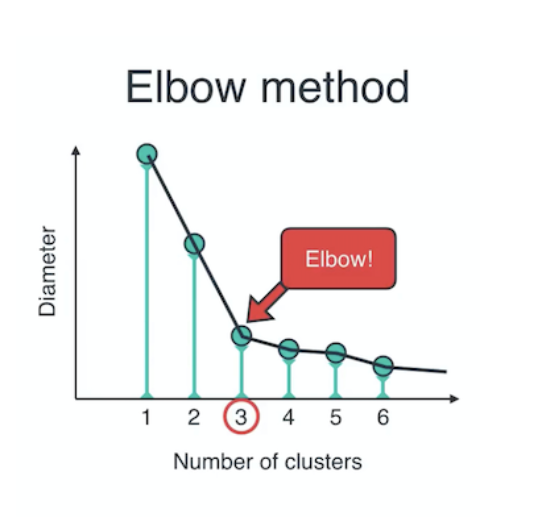

In [115]:
wcss=[]
for i in range(1,11):
    km=KMeans(n_clusters=i,max_iter=10,random_state=0)
    km.fit(x)
    wcss.append(km.inertia_) # inertia_float: Sum of squared distances of samples to their closest cluster center

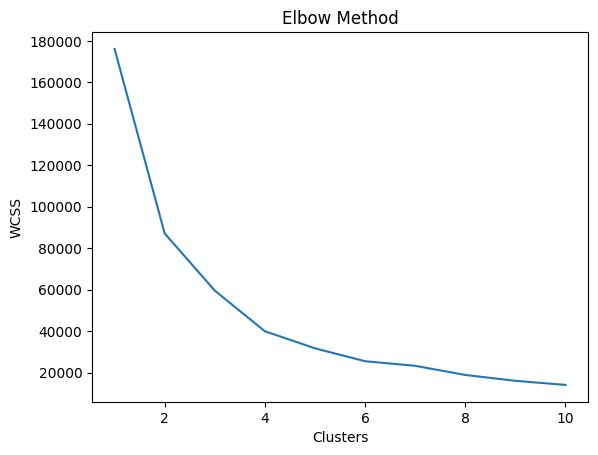

In [99]:
#plot the elbow
plt.plot(range(1,11), wcss)
plt.title('Elbow Method')
plt.xlabel('Clusters')
plt.ylabel('WCSS')
plt.show()


### Silhouette Score

The silhouette score is a metric used to evaluate the quality of clusters formed by the k-means algorithm. It measures how similar an object is to its own cluster compared to other clusters, with higher scores indicating better-defined clusters.

In [50]:
from sklearn.metrics import silhouette_score

In [116]:
km =KMeans(n_clusters=3,max_iter=300, n_init= 10, random_state = 0)
km.fit_predict(x)

array([1, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 1, 2,
       0, 2, 0, 2, 1, 1, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 1, 2, 1, 1,
       0, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2,
       1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 0, 2, 1, 2, 0, 2, 0, 2,
       1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 1, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2], dtype=int32)

In [117]:
score= silhouette_score(x, km.labels_, metric='euclidean')

In [122]:
print('Silhouette Score:%.2f '%score)

Silhouette Score:0.45 
